<a href="https://colab.research.google.com/github/APermata7/part-counting-station/blob/main/Capstone_Trainning_CLAHE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -qr requirements.txt
!pip install -q roboflow

Cloning into 'yolov5'...
remote: Enumerating objects: 17968, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 17968 (delta 78), reused 30 (delta 30), pack-reused 17866 (from 3)
Receiving objects: 100% (17968/17968), 17.11 MiB | 24.92 MiB/s, done.
Resolving deltas: 100% (12222/12222), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.2 MB/s eta 0:00:00


## CLAHE


In [ ]:
import cv2
import torch
import matplotlib.pyplot as plt
%matplotlib inline

# Load model yang sudah dilatih
model = torch.hub.load('ultralytics/yolov5', 'custom',
                        path='runs/train/model_epson_gabungan/weights/best.pt',
                        force_reload=False)
model.conf = 0.5

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def load_image(img_path):
    """Load gambar dalam format apapun, selalu kembalikan BGR 3-channel"""
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"❌ Gagal membaca: {img_path}")
        return None
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)
    elif img.shape[2] == 3:
        pass
    else:
        print(f"❌ Format tidak dikenal: {img.shape} untuk {img_path}")
        return None
    return img

def apply_clahe(img_bgr):
    """Apply CLAHE pada channel L (LAB)"""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

# ============================================
# TESTING SEMUA FORMAT DENGAN CLAHE
# ============================================
print("=" * 65)
print("TEST CLAHE — SEMUA FORMAT GAMBAR (clipLimit=2.0, tile=8×8)")
print("=" * 65)

# Gunakan gambar dari folder test_baru (atau ganti dengan folder Anda)
test_folder = "/content/test_baru"
extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff', '*.tif', '*.webp']
all_images = []
for ext in extensions:
    all_images.extend(glob.glob(f"{test_folder}/{ext}"))

if len(all_images) == 0:
    print("❌ Tidak ada gambar ditemukan")

for img_path in sorted(all_images):
    img = load_image(img_path)
    if img is None:
        continue

    img_clahe = apply_clahe(img)

    # Deteksi Original
    results_orig = model(img)
    count_orig = len(results_orig.xyxy[0])

    # Deteksi CLAHE
    results_clahe = model(img_clahe)
    count_clahe = len(results_clahe.xyxy[0])

    diff = abs(count_orig - count_clahe)
    if diff == 0:
        status = "✅ SAMA"
    elif count_clahe > count_orig:
        status = f"📈 NAIK {diff}"
    else:
        status = f"📉 TURUN {diff}"

    ext = os.path.splitext(img_path)[1].upper()
    print(f"\n[{ext}] {img_path}")
    print(f"  Original: {count_orig} part | CLAHE: {count_clahe} part | {status}")

    # Visualisasi
    img_orig_det = cv2.cvtColor(results_orig.render()[0], cv2.COLOR_BGR2RGB)
    img_clahe_det = cv2.cvtColor(results_clahe.render()[0], cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_orig_det)
    axes[0].set_title(f"ORIGINAL [{ext}]: {count_orig} part", fontsize=13, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(img_clahe_det)
    axes[1].set_title(f"CLAHE [{ext}]: {count_clahe} part", fontsize=13, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

print("\n✅ Test selesai. CLAHE dengan clipLimit=2.0, tileGridSize=(8,8) aman digunakan.")

You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


YOLOv5 🚀 2026-5-22 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


TEST CLAHE — SEMUA FORMAT GAMBAR (clipLimit=2.0, tile=8×8)


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



[.JPEG] /content/test_baru/sample1 (1).jpeg
  Original: 24 part | CLAHE: 23 part | 📉 TURUN 1


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



[.JPEG] /content/test_baru/sample1 (2).jpeg
  Original: 22 part | CLAHE: 25 part | 📈 NAIK 3

[.PNG] /content/test_baru/sample3.png
  Original: 22 part | CLAHE: 21 part | 📉 TURUN 1


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



✅ Test selesai. CLAHE dengan clipLimit=2.0, tileGridSize=(8,8) aman digunakan.


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


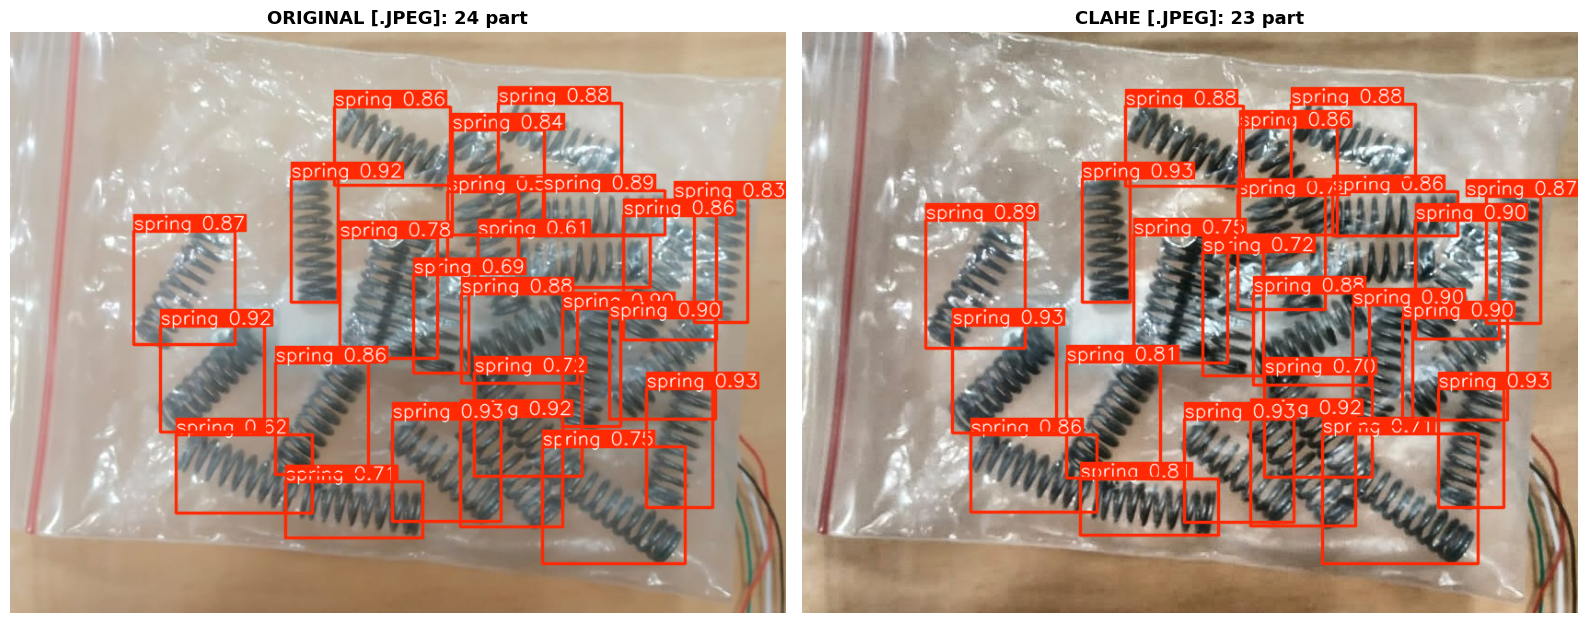

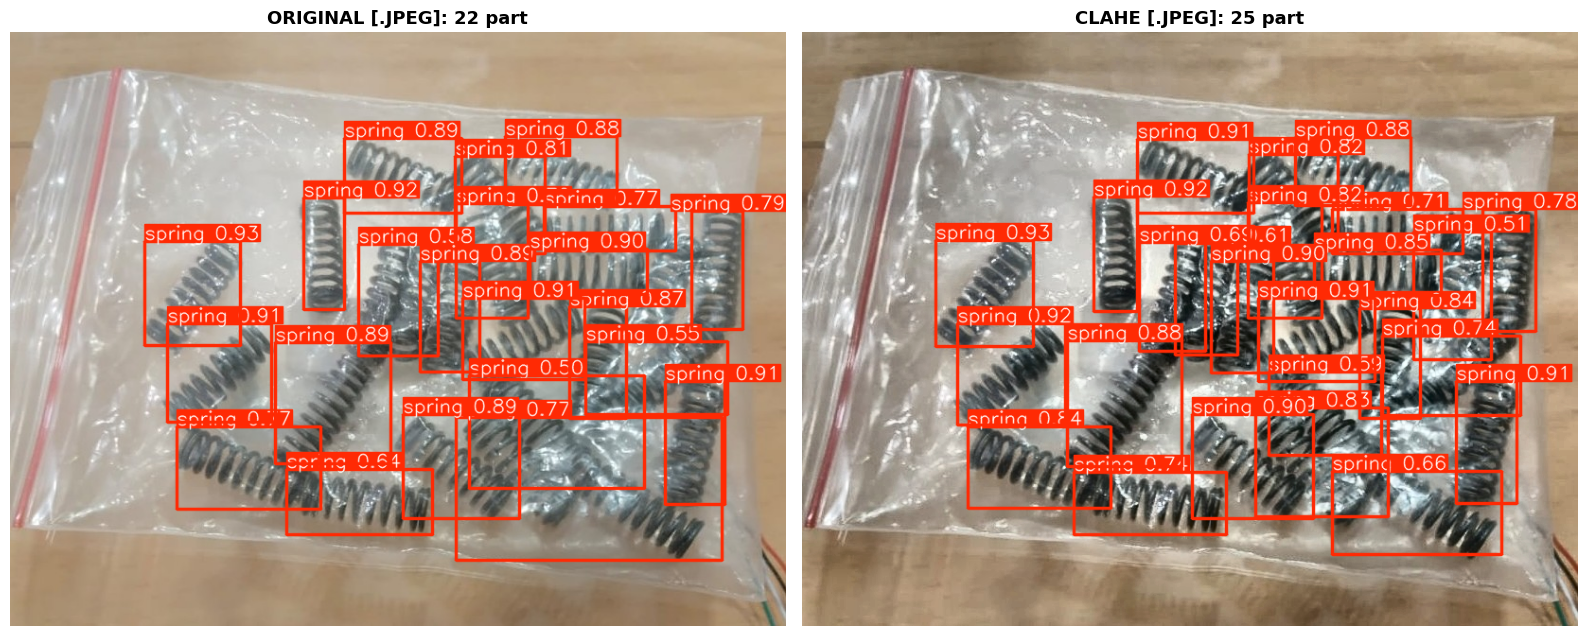

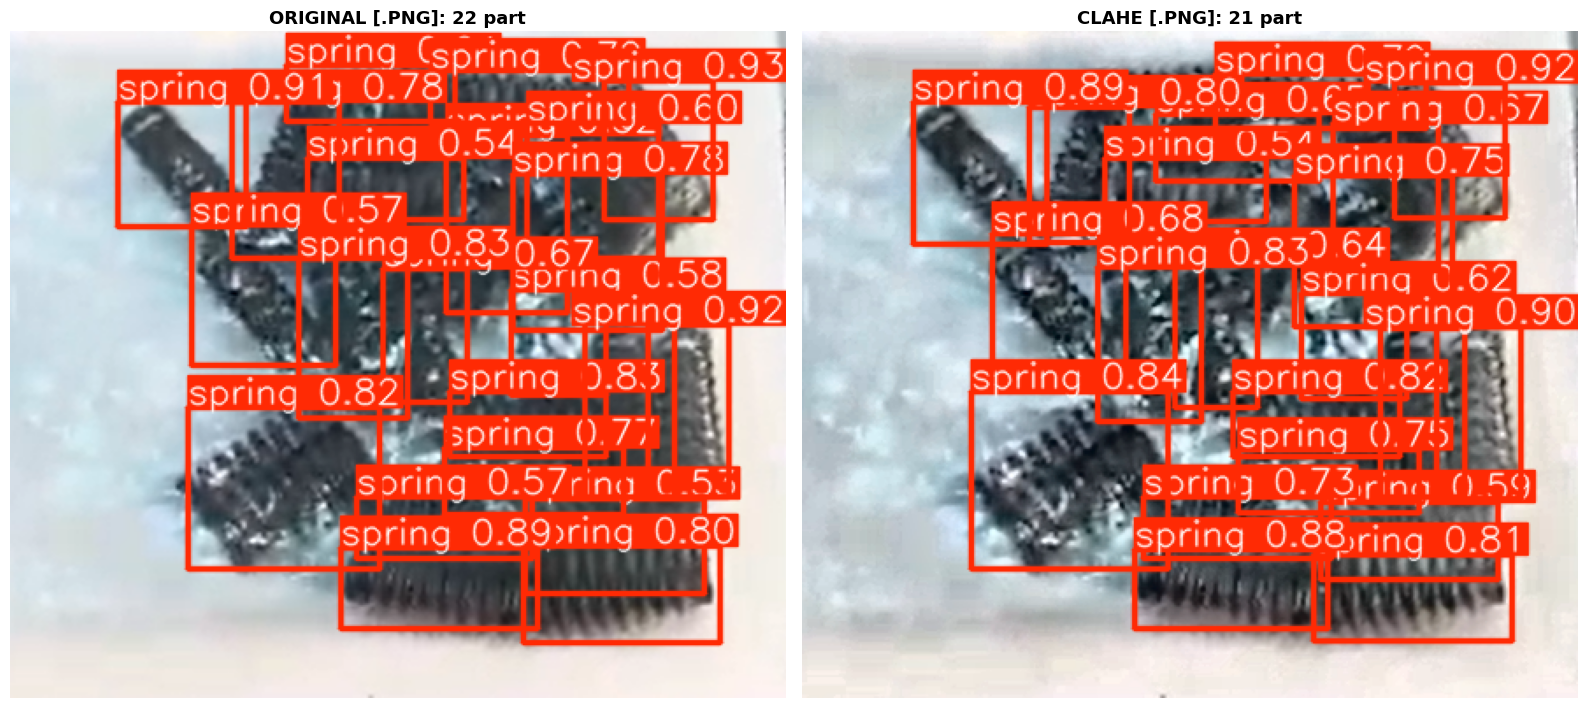

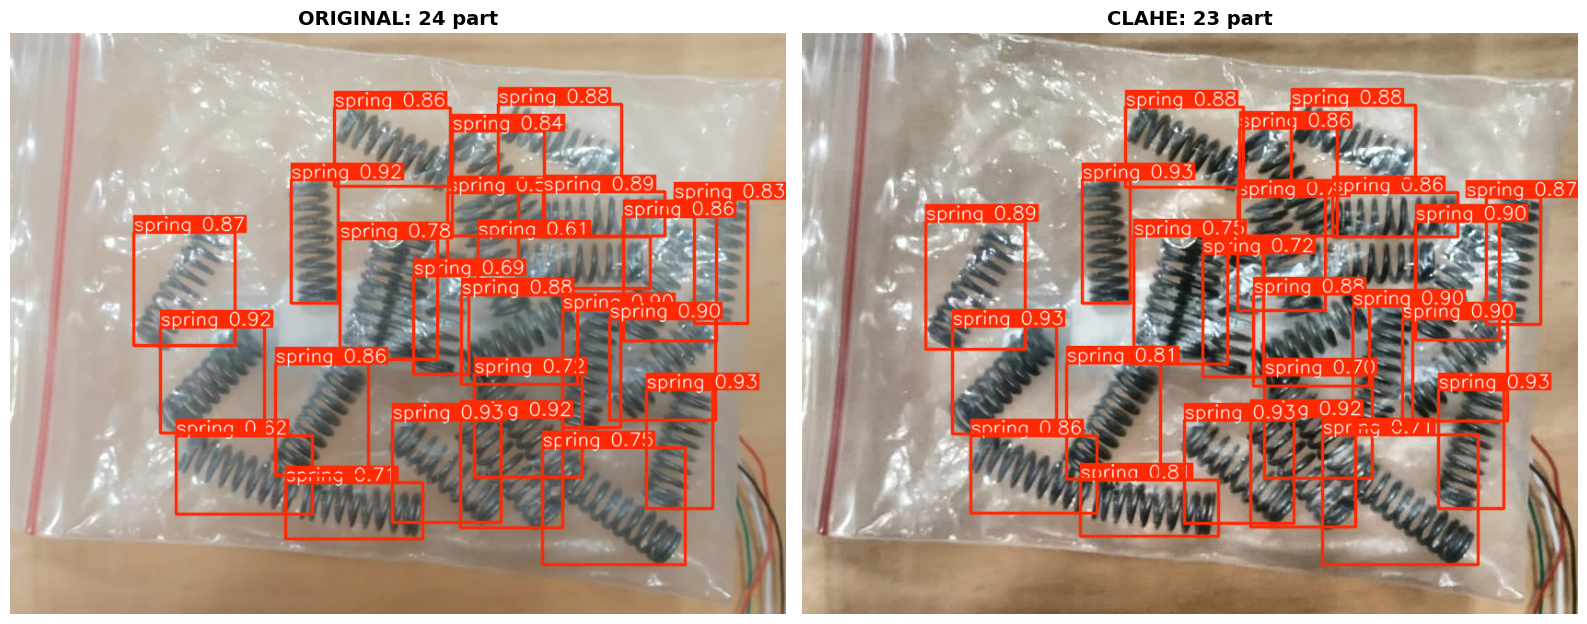

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


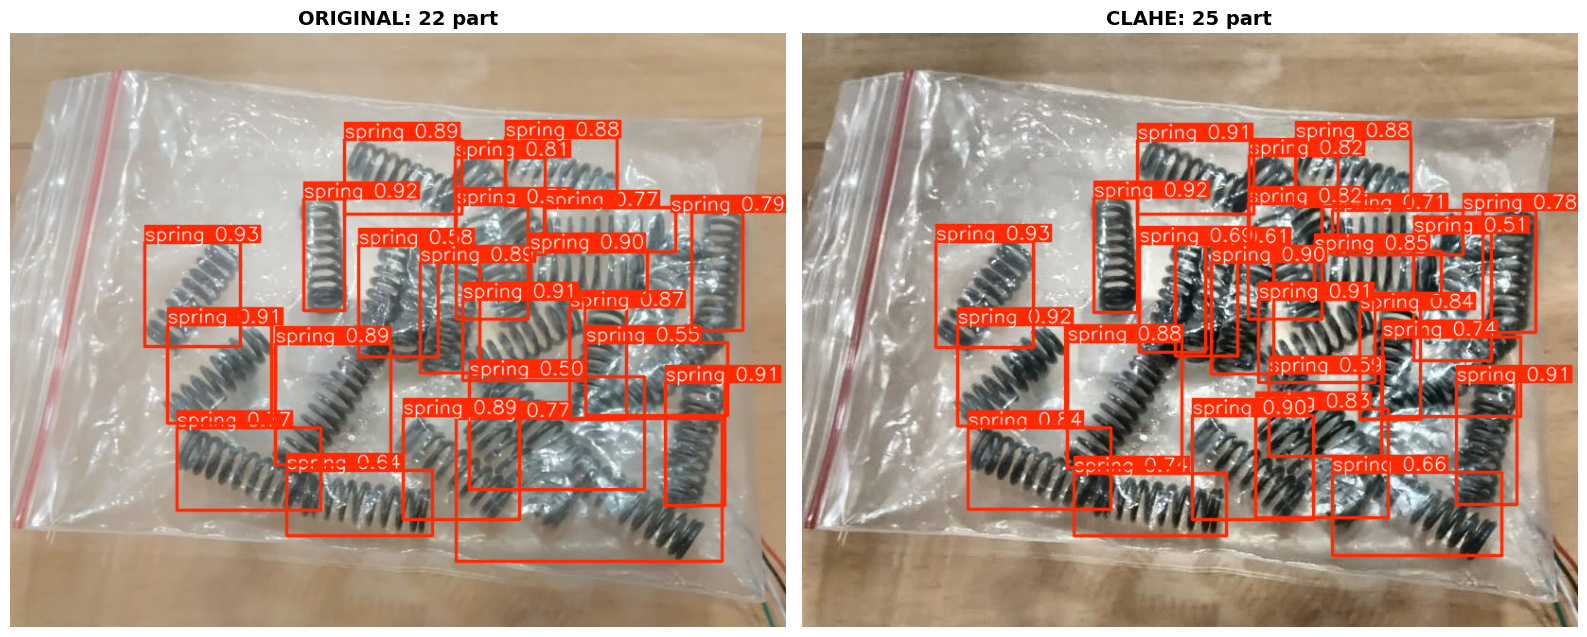

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


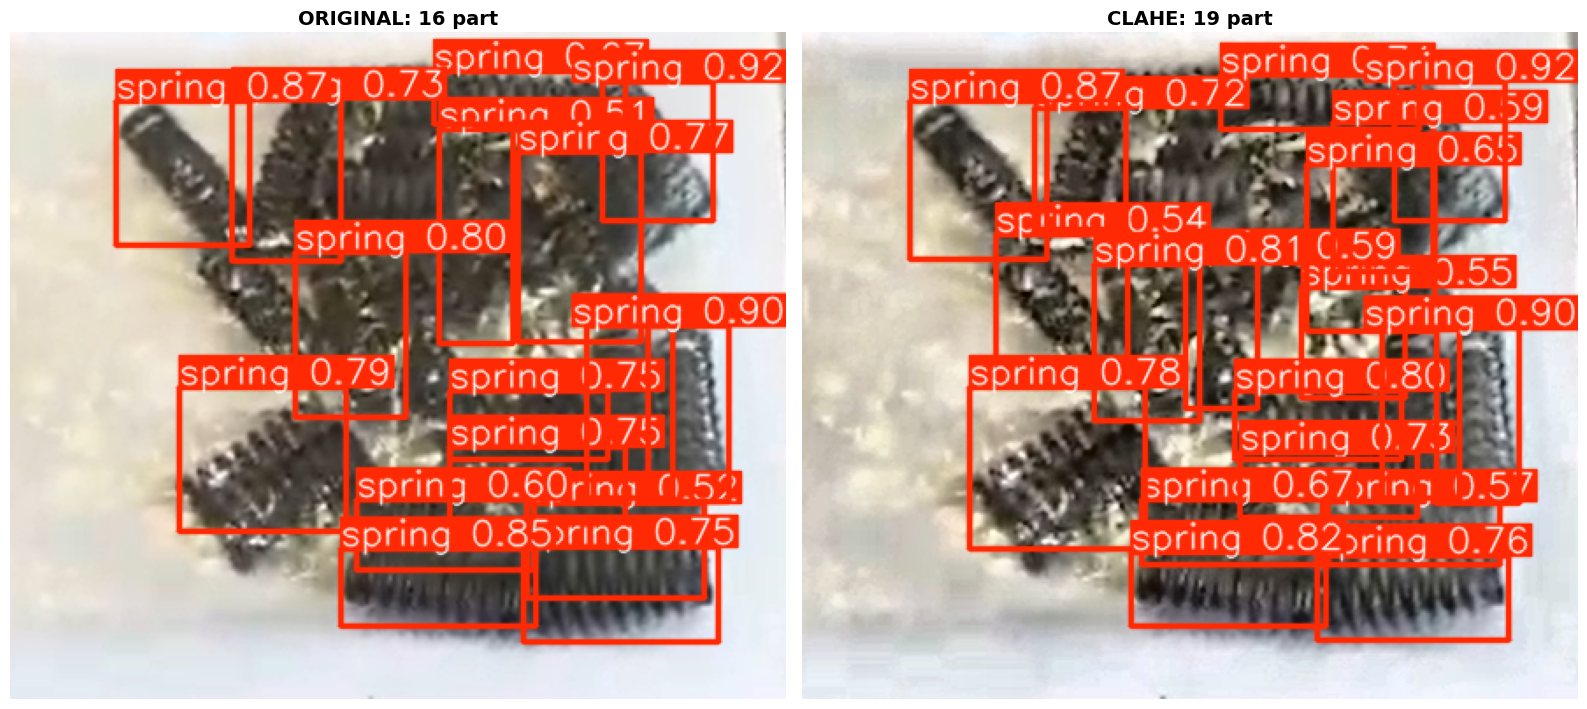

In [ ]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def apply_clahe(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

test_folder = "/content/test_baru"

for img_path in sorted(glob.glob(f"{test_folder}/*.*")):
    img = cv2.imread(img_path)
    if img is None:
        continue

    img_clahe = apply_clahe(img)

    results_orig = model(img)
    results_clahe = model(img_clahe)

    count_orig = len(results_orig.xyxy[0])
    count_clahe = len(results_clahe.xyxy[0])

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].imshow(cv2.cvtColor(results_orig.render()[0], cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"ORIGINAL: {count_orig} part", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(results_clahe.render()[0], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"CLAHE: {count_clahe} part", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()